Notebook to analyze the humber of cryptic pockets we find

In [120]:
import os

import pandas as pd

### Number of cryptic pockets detected

In [4]:
csv_path = "/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/results/02_cryptic_pocket_detection/00_detecting_based_on_volume/output_250730/cryptic_pockets.csv"
df = pd.read_csv(csv_path, sep=";")
df

,dyn_id,traj_id,pocket_id,n_closed_start,n_max_open,perc_open,perc_closed,perc_inter
0,4,10140,0,0,289,100.000000,0.000000,0.000000
1,4,10140,10,0,82,64.013841,0.000000,35.986159
2,4,10140,11,289,0,0.000000,100.000000,0.000000
3,4,10140,12,289,0,0.000000,100.000000,0.000000
4,4,10140,13,289,0,0.000000,100.000000,0.000000
...,...,...,...,...,...,...,...,...
23768,1111,18511,5,0,481,100.000000,0.000000,0.000000
23769,1111,18511,6,0,455,96.673597,0.000000,3.326403
23770,1111,18511,7,0,481,100.000000,0.000000,0.000000
23771,1111,18511,8,0,21,23.492723,0.000000,76.507277


These are the cryptic pockets we find when we consider cryptic as closed for at least 10% of the simulation (50 ns) and open for the same amount of time

In [8]:
df_m = df.copy()
df_m = df_m[df_m["perc_open"] > 10]
df_m = df_m[df_m["perc_closed"] > 10]
df_m
# df_m.to_csv("/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/results/02_cryptic_pocket_detection/00_detecting_based_on_volume/cryptic_pockets_filtered_10perc.csv", sep=";", index=False)

If we also add the condition to start as open, we have fewer:

In [9]:
df_m = df.copy()
df_m = df_m[df_m["perc_open"] > 10]
df_m = df_m[df_m["perc_closed"] > 10]
df_m = df_m[df_m["n_closed_start"] > 1] # 5 ns
# df_m.to_csv("/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/results/02_cryptic_pocket_detection/00_detecting_based_on_volume/cryptic_pockets_filtered_10perc_and_closestart.csv", sep=";", index=False)
df_m

,dyn_id,traj_id,pocket_id,n_closed_start,n_max_open,perc_open,perc_closed,perc_inter
62,7,10166,8,2,53,29.281768,57.458564,13.259669
128,11,10187,0,34,85,26.403326,53.430353,20.166320
141,11,10187,4,4,31,13.721414,49.272349,37.006237
142,11,10187,5,64,102,29.106029,61.954262,8.939709
160,12,10193,9,224,27,17.879418,46.569647,35.550936
...,...,...,...,...,...,...,...,...
23710,1109,18493,4,2,61,46.985447,11.018711,41.995842
23713,1109,18493,7,7,194,69.022869,10.602911,20.374220
23719,1110,18501,5,102,72,26.819127,35.343035,37.837838
23723,1110,18502,3,8,64,20.166320,19.958420,59.875260


### Location of cryptic pockets

In [131]:
# Load your pocket location data
csv_path = "/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/results/02_cryptic_pocket_detection/02_selecting_10percent/01_360location/pocket_360_locations.csv"  # Update this path
pocket_df = pd.read_csv(csv_path)

# Filter to remove duplicates within 10-degree bins (0-9, 10-19, 20-29, etc.) 
# but only for the same individual pocket (same dynid, trajid, pocketid)
pocket_df['angle_bin'] = (pocket_df['angle_deg'] // 10) * 10  # Create bin labels: 0, 10, 20, 30...
pocket_df = pocket_df.drop_duplicates(subset=['dynid', 'trajid', 'pocketid', 'angle_bin'], keep='first')

pocket_df


,dynid,trajid,pocketid,vertical_position,angle_deg,angle_bin
0,41,10438,19,IC,335,330
2,41,10438,19,IC,341,340
17,41,10438,19,IC,351,350
39,70,10691,0,MID,352,350
41,70,10691,0,MID,348,340
...,...,...,...,...,...,...
98129,822,15925,6,IC,7,0
98153,24,10295,7,IC,63,60
98154,24,10295,7,IC,73,70
98160,24,10295,7,IC,80,80


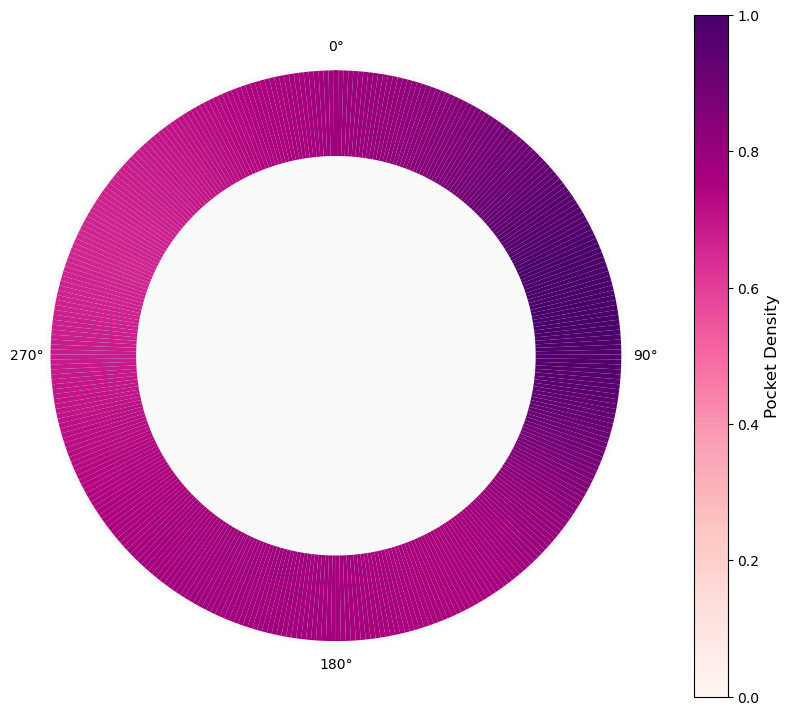

In [137]:
# Create a smooth circular heatmap using kernel density estimation
from scipy.stats import gaussian_kde

df_mod = pocket_df[pocket_df["vertical_position"] == 'EC']
angles_deg = df_mod['angle_bin'].values


# Create a smooth density estimate
angles_rad = np.deg2rad(angles_deg)

# Handle circular data by duplicating at boundaries
angles_extended = np.concatenate([angles_rad - 2*np.pi, angles_rad, angles_rad + 2*np.pi])
kde = gaussian_kde(angles_extended, bw_method=0.1)

# Evaluate density at regular intervals
eval_angles = np.linspace(0, 2*np.pi, 360)
density = kde(eval_angles)
density = density / density.max()  # normalize

# Create circular heatmap
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': 'polar'})
ax.set_facecolor('#fafafa')

# Plot as ring
r_inner, r_outer = 0.7, 1.0
width = 2*np.pi / len(eval_angles)
cmap = plt.cm.RdPu

for angle, dens in zip(eval_angles, density):
    ax.bar(angle, r_outer - r_inner, width=width, bottom=r_inner,
           color=cmap(dens), edgecolor='none')

# Aesthetics
ax.set_yticklabels([])
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_xticks(np.deg2rad([0, 90, 180, 270]))
ax.set_xticklabels(['0°','90°','180°','270°'])
ax.grid(color='gray', alpha=0, linestyle=':')
ax.spines['polar'].set_visible(False)
# ax.set_title("Cryptic Pocket Density Heatmap", fontsize=16, pad=20)

# Add colorbar
sm = plt.cm.ScalarMappable(cmap=cmap, norm=plt.Normalize(0, 1))
cbar = plt.colorbar(sm, ax=ax, pad=0.1, fraction=0.05)
cbar.set_label('Pocket Density', fontsize=12)

plt.tight_layout()
plt.show()

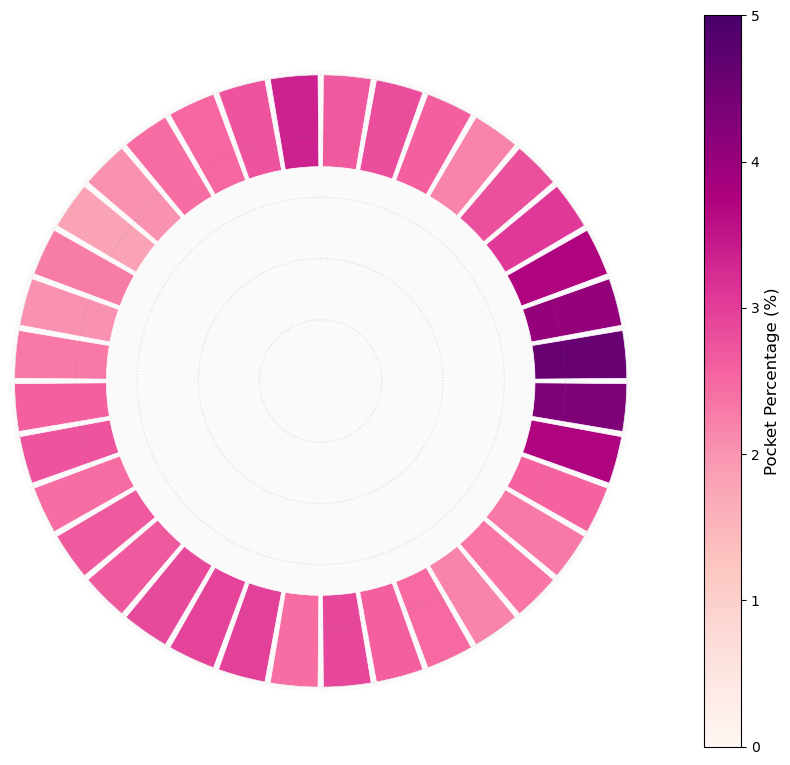

In [136]:
vertical_position = 'ec'

df_mod = pocket_df[pocket_df["vertical_position"] == vertical_position.upper()]
angles_deg = df_mod['angle_bin'].values

# Create circular heatmap with discrete 10-degree bins showing pocket percentages

# Create 36 bins of 10 degrees each
bin_width = 10  # degrees
bins = np.arange(0, 360 + bin_width, bin_width)
bin_centers = (bins[:-1] + bins[1:]) / 2.0

# Count pockets in each bin
counts, _ = np.histogram(angles_deg, bins=bins)
total_pockets = len(angles_deg)

# Convert counts to percentages
percentages = (counts / total_pockets) * 100

# Convert to radians for polar plot
theta = np.deg2rad(bin_centers)
width = np.deg2rad(bin_width)

# Fixed color scale
scale_min, scale_max = 0.0, 5.0
norm = plt.Normalize(scale_min, scale_max)
cmap = plt.cm.RdPu

# Create circular heatmap
fig, ax = plt.subplots(figsize=(8,8), subplot_kw={'projection': 'polar'})
ax.set_facecolor('#fafafa')

# Plot as ring with discrete bins
r_inner, r_outer = 0.7, 1.0

for angle, perc in zip(theta, percentages):
    color = cmap(norm(perc))
    ax.bar(angle, r_outer - r_inner, width=width*0.9, bottom=r_inner,
           color=color, edgecolor='white', linewidth=0.5)

# Aesthetics
ax.set_yticklabels([])
ax.set_theta_zero_location("N")
ax.set_theta_direction(-1)
ax.set_xticks([])
ax.set_xticklabels([])
ax.grid(color='gray', alpha=0.25, linestyle=':')
ax.spines['polar'].set_visible(False)

# Add colorbar with fixed 0-6% scale
sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # for matplotlib < 3.6 compatibility
cbar = plt.colorbar(sm, ax=ax, pad=0.1, fraction=0.05)
cbar.set_label('Pocket Percentage (%)', fontsize=12)

plt.tight_layout()
# plt.show()

figures_dir = "/home/alex/sshfs_mountpoints/verde/Documents/pocket_tool/docs/figures/raw"
plt.savefig(os.path.join(figures_dir, f"cryptic_pocket_dist_{vertical_position}.svg"))